In [1]:
from sklearn.utils import resample

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [2]:
# Step 2: Load the dataset
df = pd.read_csv("Dataset/diabetes_prediction_dataset.csv")
df.shape

(100000, 9)

In [3]:
df_non_diabetic_oversampled = df[df['diabetes'] == 0.0]
df_diabetic = df[df['diabetes'] == 1.0]

df_non_diabetic = resample(
    df_non_diabetic_oversampled,
    replace=False,
    n_samples=len(df_diabetic),
    random_state=42
)
print(len(df_non_diabetic))
print(len(df_diabetic))
# Step 5: Combine into a balanced DataFrame
df = pd.concat([df_diabetic, df_non_diabetic])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

8500
8500


In [4]:
len(df)

17000

In [5]:
df
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
df = df[df['gender'] != 'other']
# Map Male = 0, Female = 1
gender_map = {'male': 0, 'female': 1}
df['gender'] = df['gender'].map(gender_map)
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,27.0,0,0,No Info,23.91,5.0,160,0
1,1,67.0,0,0,never,29.93,6.2,159,1
2,1,11.0,0,0,not current,18.46,6.6,80,0
3,0,41.0,0,0,never,37.10,8.8,220,1
4,1,53.0,0,0,never,44.90,6.8,300,1
...,...,...,...,...,...,...,...,...,...
16995,1,65.0,0,0,never,21.51,3.5,159,0
16996,1,54.0,0,0,never,25.78,5.0,80,0
16997,1,60.0,0,0,never,39.28,6.5,155,1
16998,1,60.0,0,0,No Info,17.91,8.2,126,1


In [6]:
print(df['smoking_history'].unique())


['No Info' 'never' 'not current' 'current' 'ever' 'former']


In [7]:
df['smoking_history'] = df['smoking_history'].astype(str).str.strip().str.lower()


In [8]:
# Step 2: Map into yes / no / former
df['smoking_history'] = df['smoking_history'].replace({
    'current': 'yes',
    'former': 'former',
    'ever': 'former',
    'not current': 'former',
    'never': 'no',
    'no info': 'no'   # or 'unknown' if you want to track that separately
})

In [9]:
smoking_map = {'no': 0, 'former': 1, 'yes': 2}
df['smoking_history'] = df['smoking_history'].map(smoking_map)


In [10]:


# df = df.rename(columns={'smoking_encoded': 'smoking_history'})
df


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,27.0,0,0,0,23.91,5.0,160,0
1,1,67.0,0,0,0,29.93,6.2,159,1
2,1,11.0,0,0,1,18.46,6.6,80,0
3,0,41.0,0,0,0,37.10,8.8,220,1
4,1,53.0,0,0,0,44.90,6.8,300,1
...,...,...,...,...,...,...,...,...,...
16995,1,65.0,0,0,0,21.51,3.5,159,0
16996,1,54.0,0,0,0,25.78,5.0,80,0
16997,1,60.0,0,0,0,39.28,6.5,155,1
16998,1,60.0,0,0,0,17.91,8.2,126,1


In [11]:
# Step 4: Split into features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [12]:
# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [14]:
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'scale_pos_weight': [1]  # since you already chose this
}


In [15]:
# from sklearn.model_selection import StratifiedKFold

# stratified_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


xgb = XGBClassifier(
    use_label_encoder=True,
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,  # You can increase this for deeper search
    scoring='f1',  # Or 'roc_auc' if you want AUC
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [16]:
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score on CV:", random_search.best_score_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Best F1 Score on CV: 0.9129548267344861


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:56:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Confusion Matrix:
 [[1522  178]
 [ 119 1581]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.91      1700
           1       0.90      0.93      0.91      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



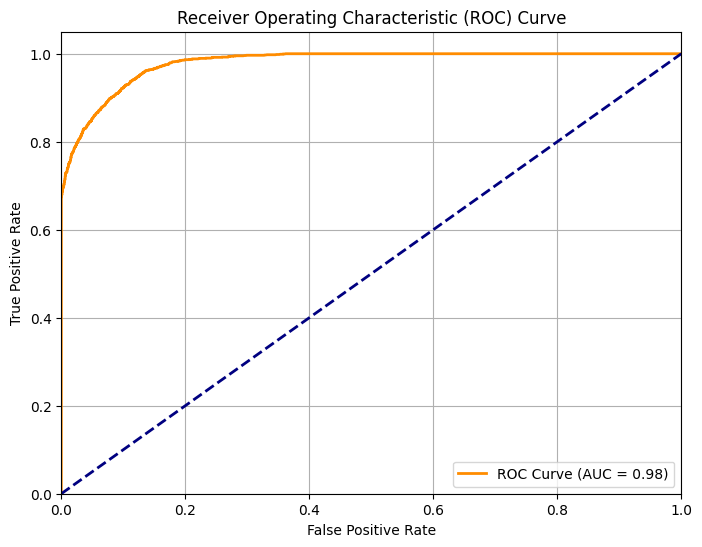

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_prob = random_search.best_estimator_.predict_proba(X_test)[:, 1]  # Probability of class 1
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


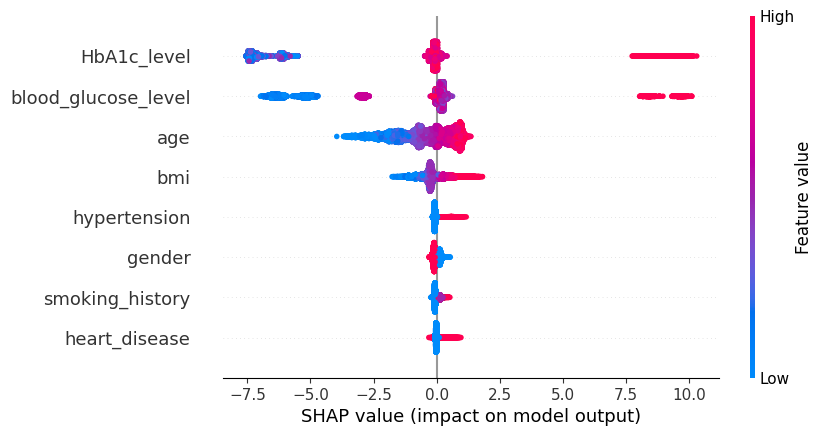

In [ ]:
import shap
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

best_f1 = 0
best_thresh = 0.5
for t in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best threshold: {best_thresh}, Best F1: {best_f1}")


Best threshold: 0.4099999999999998, Best F1: 0.8096839273705447
